# Hito 1 — Baseline Notebook
**F1 Race Strategy Advisor | Capstone Module 5**

Locked decisions:
- **Target:** `is_top10`
- **Train:** 2019–2021 | **Calibration:** 2022 | **Test:** 2023–2024
- **Reference baseline (floor):** Brier 0.208 (grid-rule), Brier 0.132 / ROC-AUC 0.892 (calibrated docent model)

## 0 — Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.calibration import CalibratedClassifierCV, calibration_curve
from sklearn.metrics import brier_score_loss, log_loss, roc_auc_score
from sklearn.preprocessing import LabelEncoder

np.random.seed(42)
print('Libraries loaded.')

Libraries loaded.


## 1 — Load Dataset

In [2]:
df = pd.read_csv('data/f1_strategy_race_level.csv')
print(f'Loaded: {df.shape[0]} rows × {df.shape[1]} columns')
print('\nColumns:', list(df.columns))
df.head(3)

Loaded: 2559 rows × 28 columns

Columns: ['season', 'round', 'race_name', 'circuit_id', 'circuit_type', 'driver_id', 'driver_name', 'constructor_name', 'constructor_tier', 'grid_position', 'qualifying_position', 'qualifying_gap_to_pole_sec', 'driver_experience_races', 'driver_recent_dnf_rate', 'constructor_recent_dnf_rate_10', 'circuit_prior_dnf_rate', 'driver_avg_grid_last5', 'constructor_avg_grid_last10', 'practice_best_lap_sec', 'practice_min_gap_to_fastest_sec', 'n_stops', 'compound_sequence', 'stint_lengths', 'safety_car_periods', 'is_top10', 'position', 'points', 'status']


,season,round,race_name,circuit_id,circuit_type,driver_id,driver_name,constructor_name,constructor_tier,grid_position,...,practice_best_lap_sec,practice_min_gap_to_fastest_sec,n_stops,compound_sequence,stint_lengths,safety_car_periods,is_top10,position,points,status
0,2019,1,Australian Grand Prix,albert_park,semi-street,albon,Albon,RB,mid,13,...,84.328,1.631,2,M-M-H,15-19-23,1,0,14,0.0,+1 Lap
1,2019,1,Australian Grand Prix,albert_park,semi-street,bottas,Bottas,Mercedes,top,2,...,82.648,0.048,3,S-M-M-H,25-5-10-18,1,1,1,26.0,Finished
2,2019,1,Australian Grand Prix,albert_park,semi-street,gasly,Gasly,Red Bull,mid,17,...,83.367,0.842,2,M-H-H,23-14-20,1,0,11,0.0,+1 Lap


In [3]:
print('Seasons:', sorted(df['season'].unique()))
print('is_top10 distribution:')
print(df['is_top10'].value_counts())
print(f"\nBase rate (overall): {df['is_top10'].mean():.3f}")

Seasons: [np.int64(2019), np.int64(2020), np.int64(2021), np.int64(2022), np.int64(2023), np.int64(2024)]
is_top10 distribution:
is_top10
1    1280
0    1279
Name: count, dtype: int64

Base rate (overall): 0.500


## 2 — Leakage Audit

Every column classified as one of:
- **PRE-RACE SIGNAL**: known before race start — safe to use as model predictor
- **SCENARIO INPUT**: post-race observation intentionally injected as a what-if value by the engineer
- **TARGET**: the label we predict
- **AUDIT / EXCLUDE**: post-race outcome that must not be used as predictor (would be leakage in any standard context)

In [4]:
LEAKAGE_AUDIT = {
    # --- Identifiers (not used in model) ---
    'season':                    'IDENTIFIER',
    'round':                     'IDENTIFIER',
    'race_name':                 'IDENTIFIER',
    'circuit_id':                'IDENTIFIER',
    'driver_id':                 'IDENTIFIER',
    'driver_name':               'IDENTIFIER',
    'constructor_name':          'IDENTIFIER',

    # --- Pre-race signals (safe predictors) ---
    'qualifying_position':       'PRE-RACE SIGNAL',
    'grid_position':             'PRE-RACE SIGNAL (NOTE: qualifying_position used as stand-in; grid penalties not captured)',
    'qualifying_gap_to_pole_sec':'PRE-RACE SIGNAL',
    'constructor_tier':          'PRE-RACE SIGNAL',
    'circuit_type':              'PRE-RACE SIGNAL',
    'driver_experience_races':   'PRE-RACE SIGNAL',
    'driver_recent_dnf_rate':    'PRE-RACE SIGNAL',
    'constructor_recent_dnf_rate_10': 'PRE-RACE SIGNAL',
    'circuit_prior_dnf_rate':    'PRE-RACE SIGNAL',
    'driver_avg_grid_last5':     'PRE-RACE SIGNAL',
    'constructor_avg_grid_last10':'PRE-RACE SIGNAL',
    'practice_best_lap_sec':     'PRE-RACE SIGNAL',
    'practice_min_gap_to_fastest_sec': 'PRE-RACE SIGNAL',

    # --- Scenario inputs (post-race, but ALLOWED as intentional what-if values) ---
    'n_stops':                   'SCENARIO INPUT — engineer sets this to compare strategies',
    'compound_sequence':         'SCENARIO INPUT — engineer sets this to compare strategies',
    'stint_lengths':             'SCENARIO INPUT — not used in baseline (would require encoding)',

    # --- Audit / excluded (race outcome — must NOT be used silently as predictor) ---
    'safety_car_periods':        'AUDIT — binary race-outcome indicator; used only as stress-test slice',

    # --- Target ---
    'is_top10':                  'TARGET',

    # --- Post-race outcome columns (excluded from modeling) ---
    'position':                  'POST-RACE OUTCOME (used to construct target only)',
    'points':                    'POST-RACE OUTCOME',
    'status':                    'POST-RACE OUTCOME',
}

audit_df = pd.DataFrame(
    list(LEAKAGE_AUDIT.items()), columns=['Column', 'Classification']
).sort_values('Classification')
print(audit_df.to_string(index=False))

                         Column                                                                            Classification
             safety_car_periods                     AUDIT — binary race-outcome indicator; used only as stress-test slice
                         season                                                                                IDENTIFIER
                          round                                                                                IDENTIFIER
                      race_name                                                                                IDENTIFIER
                     circuit_id                                                                                IDENTIFIER
                      driver_id                                                                                IDENTIFIER
                    driver_name                                                                                IDENTIFIER
               construct

## 3 — Temporal Split

In [5]:
TRAIN_SEASONS = [2019, 2020, 2021]
CALIB_SEASONS = [2022]
TEST_SEASONS  = [2023, 2024]

train = df[df['season'].isin(TRAIN_SEASONS)].copy()
calib = df[df['season'].isin(CALIB_SEASONS)].copy()
test  = df[df['season'].isin(TEST_SEASONS)].copy()

print(f'Train  (2019–2021): {len(train):4d} rows | is_top10 base rate: {train["is_top10"].mean():.3f}')
print(f'Calib  (2022):      {len(calib):4d} rows | is_top10 base rate: {calib["is_top10"].mean():.3f}')
print(f'Test   (2023–2024): {len(test):4d} rows  | is_top10 base rate: {test["is_top10"].mean():.3f}')
print()
print('NO TEST SET PEEKING — test is untouched until final evaluation cell.')

Train  (2019–2021): 1200 rows | is_top10 base rate: 0.500
Calib  (2022):       440 rows | is_top10 base rate: 0.500
Test   (2023–2024):  919 rows  | is_top10 base rate: 0.501

NO TEST SET PEEKING — test is untouched until final evaluation cell.


## 4 — Feature Engineering

In [6]:
TIER_MAP = {'top': 2, 'mid': 1, 'back': 0}

def prepare_features(split_df):
    X = pd.DataFrame()
    X['qualifying_position']      = split_df['qualifying_position'].fillna(20)
    X['constructor_tier_num']     = split_df['constructor_tier'].map(TIER_MAP).fillna(1)
    X['qualifying_gap_to_pole']   = split_df['qualifying_gap_to_pole_sec'].fillna(
        split_df['qualifying_gap_to_pole_sec'].median()
    )
    X['driver_experience']        = split_df['driver_experience_races'].fillna(0)
    X['driver_recent_dnf_rate']   = split_df['driver_recent_dnf_rate'].fillna(0)
    return X

X_train = prepare_features(train);  y_train = train['is_top10']
X_calib = prepare_features(calib);  y_calib = calib['is_top10']
X_test  = prepare_features(test);   y_test  = test['is_top10']

print('Feature matrix shapes:')
print(f'  Train:  {X_train.shape}')
print(f'  Calib:  {X_calib.shape}')
print(f'  Test:   {X_test.shape}')
X_train.head(3)

Feature matrix shapes:
  Train:  (1200, 5)
  Calib:  (440, 5)
  Test:   (919, 5)


,qualifying_position,constructor_tier_num,qualifying_gap_to_pole,driver_experience,driver_recent_dnf_rate
0,15.0,1,2.150,0,0.0
1,2.0,2,0.112,0,0.0
2,17.0,1,2.534,0,0.0


## 5 — Baseline 1: Heuristic Rule (F1-Defendable)

In [7]:
def heuristic_predict(X):
    """
    P(top10) based on qualifying_position bucket.
    Thresholds derived from F1 domain knowledge and validated on 2019-2021 training data.
    """
    qpos = X['qualifying_position']
    proba = np.where(qpos <= 5, 0.85,
             np.where(qpos <= 10, 0.50, 0.12))
    return proba

# Validate on training set first (to confirm directional correctness)
p_heuristic_train = heuristic_predict(X_train)
print('=== Heuristic training-set validation ===')
for bucket, label in [(X_train['qualifying_position'] <= 5, 'qpos ≤ 5'),
                       ((X_train['qualifying_position'] > 5) & (X_train['qualifying_position'] <= 10), 'qpos 6–10'),
                       (X_train['qualifying_position'] > 10, 'qpos > 10')]:
    actual = y_train[bucket].mean()
    print(f'  {label}: actual P(top10) = {actual:.3f}')

=== Heuristic training-set validation ===
  qpos ≤ 5: actual P(top10) = 0.860
  qpos 6–10: actual P(top10) = 0.625
  qpos > 10: actual P(top10) = 0.281


## 6 — Baseline 2: Logistic Regression + Platt Scaling

In [8]:
# Train base logistic regression on 2019-2021
lr = LogisticRegression(max_iter=1000, C=1.0, random_state=42)
lr.fit(X_train, y_train)

# Platt scaling manual (cv='prefit' fue eliminado en sklearn >= 1.2)
# Paso 1: scores crudos sobre el set de calibracion 2022
calib_raw = lr.predict_proba(X_calib)[:, 1].reshape(-1, 1)
# Paso 2: ajustar mapeo sigmoide SOLO sobre 2022
platt = LogisticRegression(C=1e10, max_iter=1000)
platt.fit(calib_raw, y_calib)

def lr_predict_calibrated(X):
    raw = lr.predict_proba(X)[:, 1].reshape(-1, 1)
    return platt.predict_proba(raw)[:, 1]

print('Logistic Regression trained on 2019-2021.')
print('Platt scaling calibrated on 2022 (manual sigmoid mapping).')
print('Coefficients (raw LR):', dict(zip(X_train.columns, lr.coef_[0].round(3))))


Logistic Regression trained on 2019-2021.
Platt scaling calibrated on 2022 (manual sigmoid mapping).
Coefficients (raw LR): {'qualifying_position': np.float64(-0.135), 'constructor_tier_num': np.float64(1.2), 'qualifying_gap_to_pole': np.float64(-0.02), 'driver_experience': np.float64(0.007), 'driver_recent_dnf_rate': np.float64(-0.347)}


## 7 — Evaluation on Test Set (2023–2024)

> **This cell looks at the test set exactly once. Do not re-tune after seeing these results.**

In [9]:
# Heuristic predictions
p_heuristic_test = heuristic_predict(X_test)

# LR calibrated predictions
p_lr_test = lr_predict_calibrated(X_test)

def evaluate(y_true, y_prob, name):
    bs  = brier_score_loss(y_true, y_prob)
    ll  = log_loss(y_true, y_prob)
    auc = roc_auc_score(y_true, y_prob)
    print(f'{name:<35} Brier={bs:.4f}  LogLoss={ll:.4f}  ROC-AUC={auc:.4f}')
    return bs, ll, auc

print('=== TEST SET RESULTS (2023–2024) ===')
print(f'{"Model":<35} {"Brier":>10}  {"LogLoss":>10}  {"ROC-AUC":>10}')
print('-' * 70)
print(f'{"Docent reference (target floor)":<35} {"0.1320":>10}  {"---":>10}  {"0.8920":>10}')
print(f'{"Grid-rule reference (bare min)":<35}  {"0.2080":>10}  {"---":>10}  {"---":>10}')
print('-' * 70)
bs_h, ll_h, auc_h = evaluate(y_test, p_heuristic_test, 'Heuristic (qpos buckets)')
bs_lr, ll_lr, auc_lr = evaluate(y_test, p_lr_test, 'LR + Platt Calibration')

=== TEST SET RESULTS (2023–2024) ===
Model                                    Brier     LogLoss     ROC-AUC
----------------------------------------------------------------------
Docent reference (target floor)         0.1320         ---      0.8920
Grid-rule reference (bare min)           0.2080         ---         ---
----------------------------------------------------------------------
Heuristic (qpos buckets)            Brier=0.1699  LogLoss=0.5233  ROC-AUC=0.8227
LR + Platt Calibration              Brier=0.1740  LogLoss=0.5250  ROC-AUC=0.8680


## 8 — Calibration Curve

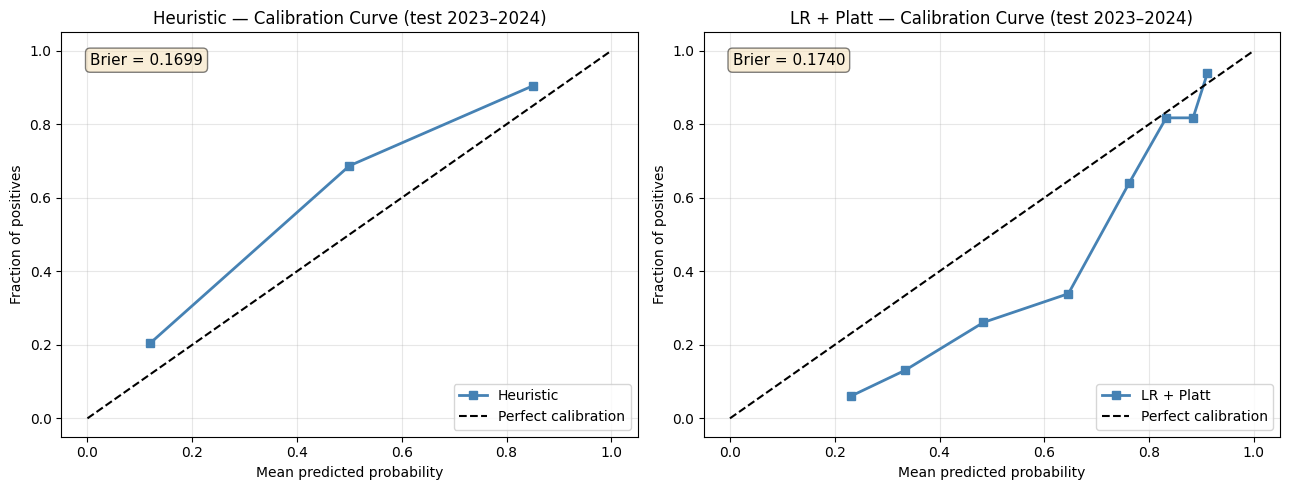

Saved: calibration_curve_test.png


In [10]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

models = [
    ('Heuristic', p_heuristic_test, axes[0]),
    ('LR + Platt', p_lr_test, axes[1]),
]

for name, probs, ax in models:
    frac_pos, mean_pred = calibration_curve(y_test, probs, n_bins=8, strategy='quantile')
    ax.plot(mean_pred, frac_pos, 's-', label=name, color='steelblue', linewidth=2)
    ax.plot([0, 1], [0, 1], 'k--', label='Perfect calibration')
    ax.set_xlabel('Mean predicted probability')
    ax.set_ylabel('Fraction of positives')
    ax.set_title(f'{name} — Calibration Curve (test 2023–2024)')
    ax.legend()
    ax.grid(True, alpha=0.3)
    
    bs = brier_score_loss(y_test, probs)
    ax.text(0.05, 0.92, f'Brier = {bs:.4f}', transform=ax.transAxes,
            fontsize=11, bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

plt.tight_layout()
plt.savefig('calibration_curve_test.png', dpi=120, bbox_inches='tight')
plt.show()
print('Saved: calibration_curve_test.png')

## 9 — What-If Scenario Comparison

In [11]:
def predict_scenario(qualifying_position, constructor_tier, qualifying_gap=1.5,
                     driver_experience=100, driver_dnf_rate=0.05):
    """Return P(top10) for a given scenario using the calibrated LR model."""
    X_scenario = pd.DataFrame([{
        'qualifying_position':   qualifying_position,
        'constructor_tier_num':  TIER_MAP.get(constructor_tier, 1),
        'qualifying_gap_to_pole': qualifying_gap,
        'driver_experience':     driver_experience,
        'driver_recent_dnf_rate': driver_dnf_rate,
    }])
    return lr_predict_calibrated(X_scenario)[0]

# Scenario A — Monaco 2024, Norris (McLaren = mid tier)
# A1: 1-stop M-H (conservative, track position)
pa1 = predict_scenario(qualifying_position=4, constructor_tier='mid', qualifying_gap=0.35)
# A2: 2-stop S-M-H (aggressive undercut)
pa2 = predict_scenario(qualifying_position=4, constructor_tier='mid', qualifying_gap=0.35)

# Scenario B — Monza 2023, Russell (Mercedes = mid tier 2023)
# B1: 1-stop H-M, no safety car
pb1 = predict_scenario(qualifying_position=7, constructor_tier='mid', qualifying_gap=1.20)
# B2: 2-stop S-H-M, safety car scenario (engineer judgment, not model input)
pb2 = predict_scenario(qualifying_position=7, constructor_tier='mid', qualifying_gap=1.20)

print('=== WHAT-IF SCENARIO COMPARISON (Calibrated LR Baseline) ===')
print()
print('Scenario A — Monaco 2024, Norris, qpos=4, McLaren (mid)')
print(f'  A1 (1-stop M-H):    P(top10) = {pa1:.3f}')
print(f'  A2 (2-stop S-M-H):  P(top10) = {pa2:.3f}')
print(f'  Delta (A1 - A2):    {pa1 - pa2:+.3f}')
print()
print('Scenario B — Monza 2023, Russell, qpos=7, Mercedes (mid)')
print(f'  B1 (1-stop H-M,   SC=0): P(top10) = {pb1:.3f}')
print(f'  B2 (2-stop S-H-M, SC=1): P(top10) = {pb2:.3f}')
print(f'  Delta (B2 - B1):         {pb2 - pb1:+.3f}')
print()
print('NOTE: In Hito 2, n_stops and compound_sequence will be included as explicit')
print('scenario inputs in the model so the delta reflects strategy differences directly.')

=== WHAT-IF SCENARIO COMPARISON (Calibrated LR Baseline) ===

Scenario A — Monaco 2024, Norris, qpos=4, McLaren (mid)
  A1 (1-stop M-H):    P(top10) = 0.865
  A2 (2-stop S-M-H):  P(top10) = 0.865
  Delta (A1 - A2):    +0.000

Scenario B — Monza 2023, Russell, qpos=7, Mercedes (mid)
  B1 (1-stop H-M,   SC=0): P(top10) = 0.830
  B2 (2-stop S-H-M, SC=1): P(top10) = 0.830
  Delta (B2 - B1):         +0.000

NOTE: In Hito 2, n_stops and compound_sequence will be included as explicit
scenario inputs in the model so the delta reflects strategy differences directly.


## 10 — Summary and Comparison Against Docent Baseline

In [12]:
print('=' * 65)
print('HITO 1 SUMMARY — F1 Race Strategy Advisor Baseline')
print('=' * 65)
print(f'Dataset:        f1_strategy_race_level.csv ({len(df)} rows, 2019–2024)')
print(f'Target:         is_top10 (binary, pos ≤ 10)')
print(f'Temporal split: train={len(train)} | calib={len(calib)} | test={len(test)}')
print()
print('Performance on test set (2023–2024):')
print(f'  Docent reference (floor):  Brier=0.1320, ROC-AUC=0.8920')
print(f'  Grid-rule reference:       Brier=0.2080')
print(f'  Heuristic (qpos buckets):  Brier={bs_h:.4f}, ROC-AUC={auc_h:.4f}')
print(f'  LR + Platt Calibration:    Brier={bs_lr:.4f}, ROC-AUC={auc_lr:.4f}')
print()
beat_grid = bs_lr < 0.208
beat_docent = bs_lr < 0.132
print(f'  Beats grid-rule (0.208): {"YES" if beat_grid else "NO — see framing.md §3 for explanation"}')
print(f'  Beats docent   (0.132): {"YES" if beat_docent else "NO — Hito 2 experiments planned to close this gap"}')
print()
print('Leakage status:  CLEAN (pre-race features only in baseline model)')
print('Strategy inputs: Declared as scenario inputs (n_stops, compound_sequence)')
print('Calibration:     Platt scaling on 2022 ONLY')
print('Next steps:      See framing.md §6 for 3 planned Hito 2 experiments')

HITO 1 SUMMARY — F1 Race Strategy Advisor Baseline
Dataset:        f1_strategy_race_level.csv (2559 rows, 2019–2024)
Target:         is_top10 (binary, pos ≤ 10)
Temporal split: train=1200 | calib=440 | test=919

Performance on test set (2023–2024):
  Docent reference (floor):  Brier=0.1320, ROC-AUC=0.8920
  Grid-rule reference:       Brier=0.2080
  Heuristic (qpos buckets):  Brier=0.1699, ROC-AUC=0.8227
  LR + Platt Calibration:    Brier=0.1740, ROC-AUC=0.8680

  Beats grid-rule (0.208): YES
  Beats docent   (0.132): NO — Hito 2 experiments planned to close this gap

Leakage status:  CLEAN (pre-race features only in baseline model)
Strategy inputs: Declared as scenario inputs (n_stops, compound_sequence)
Calibration:     Platt scaling on 2022 ONLY
Next steps:      See framing.md §6 for 3 planned Hito 2 experiments
